In [12]:
import numpy as np  
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft
import pandas as pd

RMS value: 0.7071067811865475
Expected RMS value: 0.7071067811865475


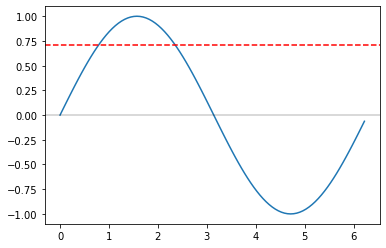

In [13]:
x = np.linspace(0, 2 * np.pi, 100, endpoint=False)
sin_signal = np.sin(x)

rms = np.sqrt(np.mean(sin_signal**2))
print("RMS value:", rms)
print("Expected RMS value:", 1/np.sqrt(2))

f, ax = plt.subplots()
ax.plot(x, sin_signal)
ax.axhline(rms, color='red', linestyle='--')
ax.axhline(0, color='k', alpha=.2)

plt.show()

In [14]:
def order_analysis(angles_0_360, signal, rpm, max_order=12):
    T = 1 / rpm   # Calcular el período de rotación en segundos por revolución
    maxIndex = len(angles_0_360) # Número de muestras en la señal
    AV_signal = np.mean(signal) # Valor medio de la señal

    # Overall como la desviación estándar de la señal
    overall = np.sqrt(np.mean((signal - AV_signal)**2))  

    # Cálculo de órdenes

    orders = []
    for i in range(1, max_order+1):
        As_sin = 0 # Componente seno del orden i
        Ac_cos = 0 # Componente coseno del orden i
      
        for idx in range(maxIndex):          

            # Convertir ángulo a tiempo relativo dentro del período de rotación
            time = angles_0_360[idx] * T / 360          

            # Proyectar la señal sobre las funciones seno y coseno del orden i
            As_sin += signal[idx] * np.sin(i * 2 * np.pi * time / T)
            Ac_cos += signal[idx] * np.cos(i * 2 * np.pi * time / T)        
        # Normalizar los coeficientes
        As_sin *= 2 / maxIndex
        Ac_cos *= 2 / maxIndex

        # Calcular la magnitud del orden i (magnitud del vector resultante)
        order_mag = np.sqrt(As_sin**2 + Ac_cos**2) / np.sqrt(2) # RMS (Root Mean Square)
        orders.append(order_mag)

    return [overall] + orders

Peaks at frequencies: [  5 395]


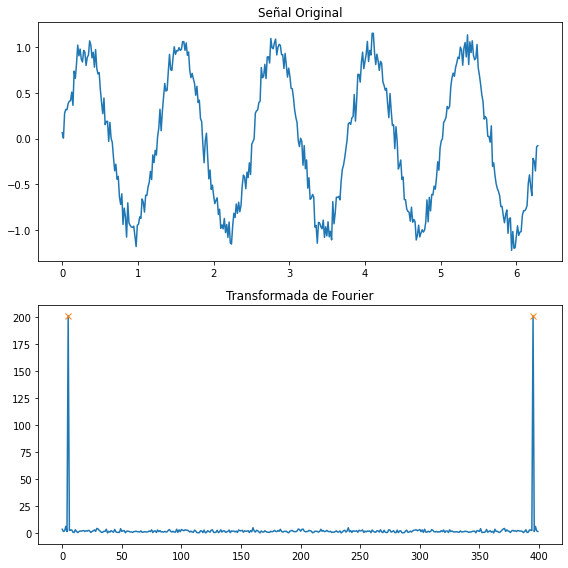

In [15]:
x = np.linspace(0, 2 * np.pi, 400)
freq = 5
y = np.sin(freq * x) + 0.1 * np.random.normal(size=x.shape)


f, ax = plt.subplots(2, 1, figsize=(8,8))
ax[0].plot(x, y)
ax[0].set_title('Señal Original')
Yf = fft(y)
ax[1].plot(np.abs(Yf))

peaks = np.where(np.abs(Yf) > 50)[0]
print("Peaks at frequencies:", peaks)
ax[1].plot(peaks, np.abs(Yf)[peaks], "x")
ax[1].set_title('Transformada de Fourier')
plt.tight_layout()
plt.show()

Peaks at frequencies: [ 15 385]


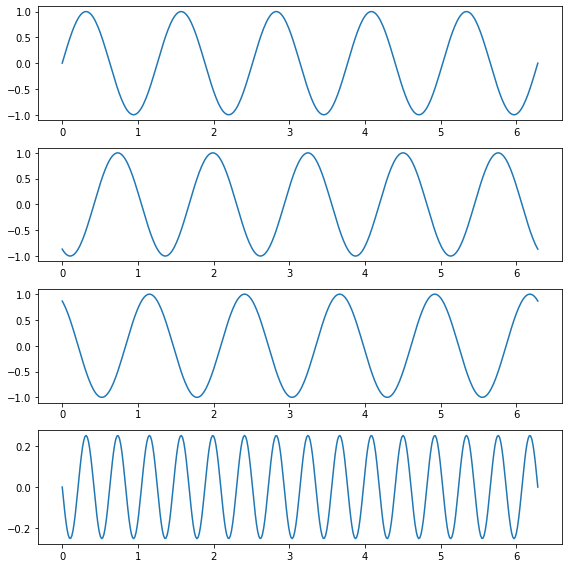

In [16]:
x = np.linspace(0, 2 * np.pi, 400)
freq = 5

y1 = np.sin(freq * x)
y2 = np.sin(freq * x - 2 * np.pi / 3)
y3 = np.sin(freq * x + 2 * np.pi / 3) 

Yf = fft(y1*y2*y3)
peaks = np.where(np.abs(Yf) > 20)[0]
print("Peaks at frequencies:", peaks)

f, ax = plt.subplots(4, 1, figsize=(8,8))
ax[0].plot(x, y1)
ax[1].plot(x, y2)
ax[2].plot(x, y3)

ax[3].plot(x, y1*y2*y3)

plt.tight_layout()
plt.show()

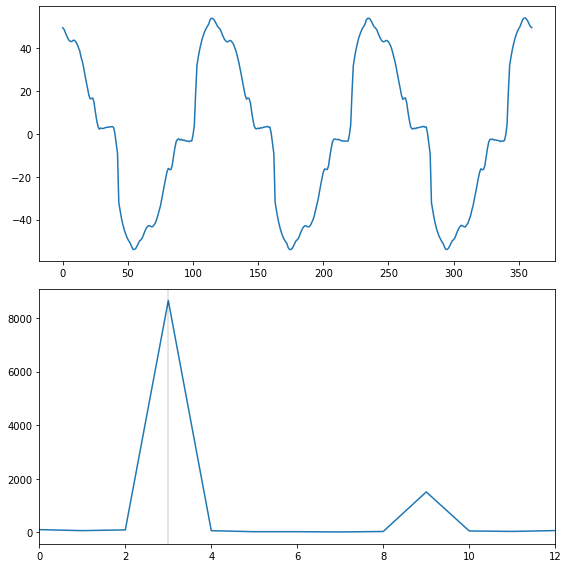

In [17]:
data = pd.read_csv('data.csv')
x = data['Angle_Rot_Spider.LastRot'].values
y = data['Force_Roller_Tulip_Total_JointRef.z'].values

f, ax = plt.subplots(2, 1, figsize=(8,8))
ax[0].plot(x, y)
Yf = fft(y)
ax[1].plot(np.abs(Yf))

ax[1].set_xlim(0, 1)
ax[1].set_xticks(np.arange(0, 13, 2))
axvline = 3
ax[1].axvline(axvline, color='k', linestyle='--', lw=.3)

plt.tight_layout()
plt.show()

In [18]:
x = data['Angle_Rot_Spider.LastRot'].values
y = data['Force_Roller_Tulip_Total_JointRef.z'].values

order_analysis(x, y, 200, max_order=12)


[34.968358012305956,
 0.21855983665338083,
 0.20116036079092406,
 33.95884197905549,
 0.19657614419293237,
 0.2048196137942782,
 0.2035242804593775,
 0.20859541362481918,
 0.1954372375014514,
 6.090350291253316,
 0.1961072918933152,
 0.19550842210262118,
 0.10071390189360385]

armónico  0: amplitud = 0.193, fase = 0.000 rad
armónico  1: amplitud = 0.241, fase = 0.013 rad
armónico  2: amplitud = 0.350, fase = -0.009 rad
armónico  3: amplitud = 33.910, fase = -0.045 rad
armónico  4: amplitud = 0.233, fase = 3.016 rad
armónico  5: amplitud = 0.083, fase = 2.928 rad
armónico  6: amplitud = 0.085, fase = 2.046 rad


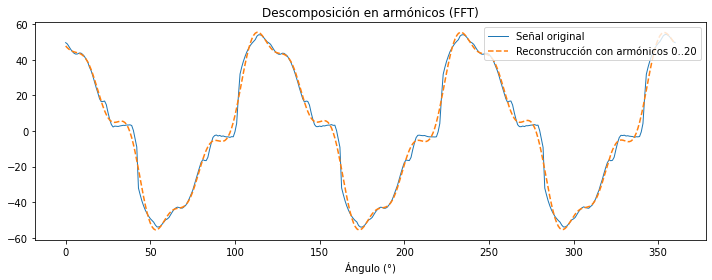

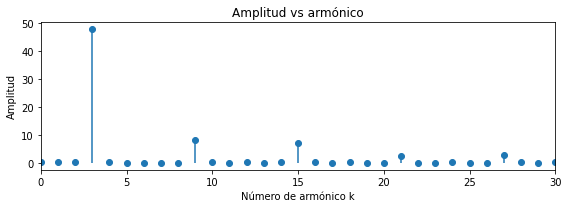

In [20]:
import numpy as np
from scipy.fft import rfft, irfft, rfftfreq
import matplotlib.pyplot as plt

angles_deg = np.linspace(0, 360, 361)  # 366 puntos
angles_rad = np.deg2rad(angles_deg)    # convertir a radianes si quieres usar seno/cos

y = data['Force_Roller_Tulip_Total_JointRef.z'].values

# --- FFT real (solo positivos) ---
N = len(y)
# rfft devuelve coeficientes de frecuencia 0..Nyquist
Y = rfft(y)
freqs = rfftfreq(N, d=1.0)  # frecuencia normalizada (ciclos por muestra)

# Pero queremos interpretar en "armónicos por periodo (360°)".
# Si tomamos una vuelta completa como k=0..N-1 armónicos, el número de armónico k es:
harmonic_numbers = np.arange(len(freqs))  # 0,1,2,... hasta Nyquist

# amplitud y fase (para señales reales)
amplitudes = (2.0 / N) * np.abs(Y)      # factor 2/N para convertir a amplitud de seno (salvo DC y Nyquist)
amplitudes[0] = np.abs(Y[0]) / N        # DC componente (no multiplicar por 2)
if N % 2 == 0:                          # si hay componente Nyquist, su amplitud no se duplica
    amplitudes[-1] = np.abs(Y[-1]) / N

phases = np.angle(Y)

# Mostrar primeros armónicos relevantes
for k in range(7):  # imprime DC + primeros 6 armónicos
    print(f"armónico {k:2d}: amplitud = {amplitudes[k]/np.sqrt(2):.3f}, fase = {phases[k]:.3f} rad")

# --- Reconstrucción usando los K armónicos más importantes ---
K = 20  # por ejemplo, usar hasta el 6º armónico
# opción 1: reconstruir con irfft después de enmascarar los coeficientes
Y_masked = Y.copy()
Y_masked[K+1:] = 0  # conservar 0..K
y_recon = irfft(Y_masked, n=N)

# opción 2: reconstruir manualmente sumando senos/cosenos (útil si quieres ver términos individuales)
t = np.arange(N)  # índice de muestra (corresponde a angle_deg)
y_manual = np.zeros_like(t, dtype=float)
for k in range(0, K+1):
    A = amplitudes[k]
    phi = phases[k]
    if k == 0:
        y_manual += (A) * np.ones_like(t)
    else:
        # reconstrucción como cos(2π k n / N + phi)
        y_manual += A * np.cos(2 * np.pi * k * t / N + phi)

# --- Plots ---
plt.figure(figsize=(10,4))
plt.plot(angles_deg, y, label='Señal original', linewidth=1)
plt.plot(angles_deg, y_recon, '--', label=f'Reconstrucción con armónicos 0..{K}', linewidth=1.5)
plt.xlabel('Ángulo (°)')
plt.legend()
plt.title('Descomposición en armónicos (FFT)')
plt.tight_layout()
plt.show()

# --- gráfico de amplitudes por armónico ---
plt.figure(figsize=(8,3))
plt.stem(harmonic_numbers, amplitudes, basefmt=" ")
plt.xlabel('Número de armónico k')
plt.ylabel('Amplitud')
plt.title('Amplitud vs armónico')
plt.xlim(0, min(30, len(harmonic_numbers)-1))
plt.tight_layout()
plt.show()
